# Genetic Algorithms — Optimisation Walkthrough

This notebook builds up from the simplest GA variant to the most sophisticated,
using the **same fitness function and budget** throughout so you can see exactly
what each extension adds.

| Step | Variant | Key addition |
|------|---------|-------------|
| 1 | `BinaryGA` | Baseline — fixed & improved original |
| 2 | `RealValuedGA` | Float encoding + SBX crossover (no bit gymnastics) |
| 3 | `AdaptiveGA` | Diversity-driven adaptive mutation σ |
| 4 | `IslandModelGA` | Multi-population ring-topology with migration |

**Objective:** maximise `z = sin(x)·cos(y) + sin(y²)·x` over `[-10, 10]²`

In [1]:
import time
import warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

warnings.filterwarnings('ignore')
%matplotlib inline
plt.rcParams.update({'figure.dpi': 110, 'font.size': 10})

from genetic_algorithms import BinaryGA, RealValuedGA, AdaptiveGA, IslandModelGA
from genetic_algorithms.visualization import (
    plot_fitness_history,
    plot_population_2d,
    plot_convergence_comparison,
    plot_sigma_adaptation,
)

# Fixed seed for reproducibility across all cells
SEED = 42
BOUNDS = [(-10.0, 10.0), (-10.0, 10.0)]
N_GENERATIONS = 50   # same budget for every single-population variant

print('All imports OK.')

All imports OK.


---
## The Optimisation Target

Before running any algorithm, it's worth looking at the landscape we're searching.
The function has multiple local maxima — a good stress test for any population-based search.

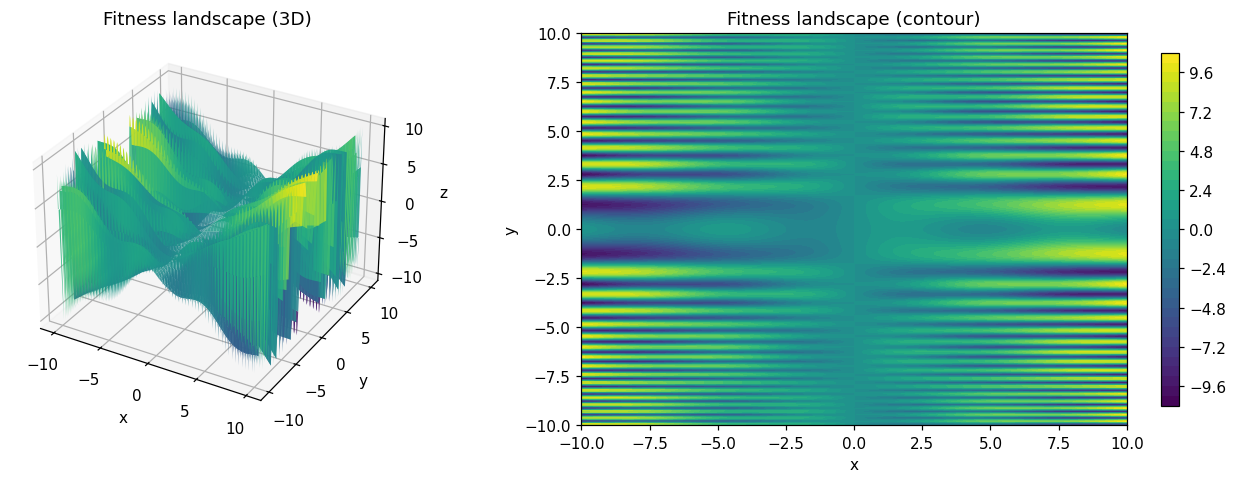

Grid max  : 10.5318  at x≈10.00, y≈-9.46
Grid min  : -10.5318
Note: the grid max is an approximation; a GA can find sharper peaks.


In [2]:
def fitness(individual):
    x, y = individual[0], individual[1]
    return np.sin(x) * np.cos(y) + np.sin(y ** 2) * x

# Build a fine grid for visualisation only
x = np.linspace(-10, 10, 300)
y = np.linspace(-10, 10, 300)
X, Y = np.meshgrid(x, y)
Z = np.sin(X) * np.cos(Y) + np.sin(Y ** 2) * X

fig = plt.figure(figsize=(13, 4.5))

ax3d = fig.add_subplot(121, projection='3d')
ax3d.plot_surface(X, Y, Z, cmap='viridis', alpha=0.85, rcount=60, ccount=60)
ax3d.set_xlabel('x'); ax3d.set_ylabel('y'); ax3d.set_zlabel('z')
ax3d.set_title('Fitness landscape (3D)')

axc = fig.add_subplot(122)
cp = axc.contourf(X, Y, Z, levels=40, cmap='viridis')
plt.colorbar(cp, ax=axc, shrink=0.9)
axc.set_xlabel('x'); axc.set_ylabel('y')
axc.set_title('Fitness landscape (contour)')

plt.tight_layout()
plt.show()

print(f'Grid max  : {Z.max():.4f}  at x≈{x[np.unravel_index(Z.argmax(), Z.shape)[1]]:.2f},'
      f' y≈{y[np.unravel_index(Z.argmax(), Z.shape)[0]]:.2f}')
print(f'Grid min  : {Z.min():.4f}')
print('Note: the grid max is an approximation; a GA can find sharper peaks.')

---
## Step 1 — Baseline: `BinaryGA`

The original implementation, now with three bugs fixed and improvements added:
- Mutation now covers **all** genome bits (previously only the first dimension was mutated)
- `best_individual` is a proper array copy, not the integer `0`
- `select_parent` returns a copy so crossover cannot corrupt the parent pool
- **Elitism**: top `elitism` individuals are carried forward unchanged every generation
- **Early stopping** via `patience` + `tol`

Each individual is a binary bitstring of length `n_bits × n_dims = 32`.
Genes are decoded to floats via: `value = lo + (int(bits, 2) / 2^n_bits) × (hi − lo)`

In [3]:
np.random.seed(SEED)

t0 = time.time()
binary_ga = BinaryGA(
    fitness, BOUNDS,
    n_bits=16,
    pop_size=200,
    n_generations=N_GENERATIONS,
    maximize=True,
    elitism=2,
    tournament_size=10,
    patience=20,
    tol=1e-5,
)
binary_solution = binary_ga.evolve()
binary_time = time.time() - t0

print(f'\nBest solution  x = {binary_solution[0]:.5f},  y = {binary_solution[1]:.5f}')
print(f'Best score     : {binary_ga.best_score:.6f}')
print(f'Generations    : {len(binary_ga.history)} / {N_GENERATIONS}')
print(f'Wall time      : {binary_time:.2f}s')

Generation    1 | Best score: 9.135060
Generation    2 | Best score: 9.449865
Generation    3 | Best score: 10.093108
Generation    4 | Best score: 10.303297
Generation    5 | Best score: 10.370070
Generation    6 | Best score: 10.481563
Generation    7 | Best score: 10.481563
Generation    8 | Best score: 10.502491
Generation    9 | Best score: 10.504388
Generation   10 | Best score: 10.508790
Generation   11 | Best score: 10.515493
Generation   12 | Best score: 10.518768
Generation   13 | Best score: 10.518768
Generation   14 | Best score: 10.518768
Generation   15 | Best score: 10.518768
Generation   16 | Best score: 10.518768
Generation   17 | Best score: 10.518768
Generation   18 | Best score: 10.518768
Generation   19 | Best score: 10.518768
Generation   20 | Best score: 10.518768
Generation   21 | Best score: 10.518768
Generation   22 | Best score: 10.519048
Generation   23 | Best score: 10.519048
Generation   24 | Best score: 10.519048
Generation   25 | Best score: 10.519048
Ge

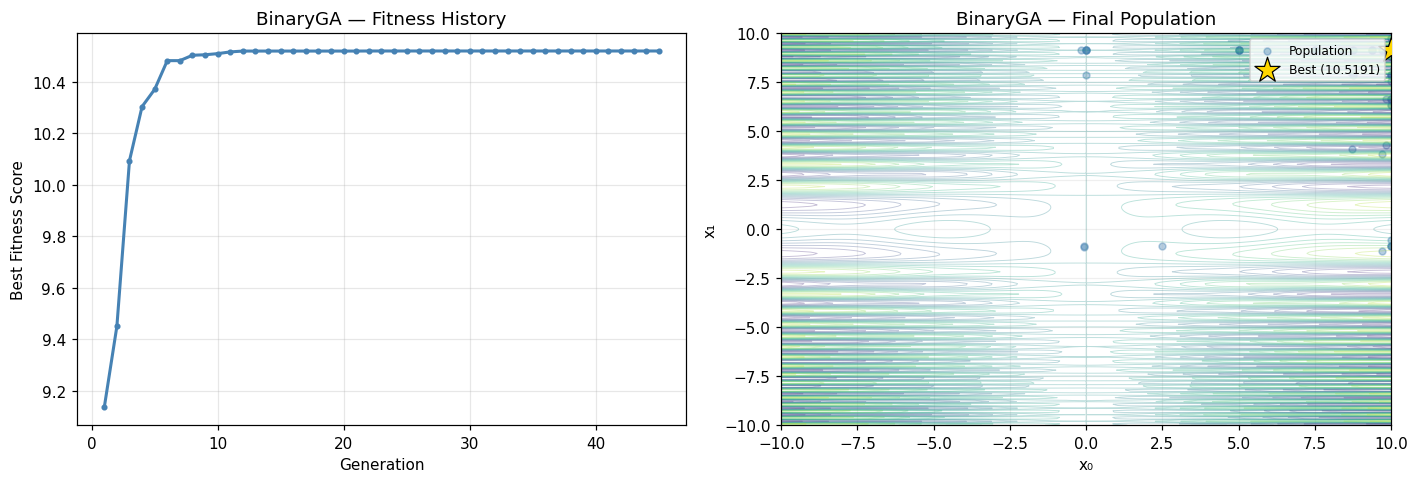

Observation: binary encoding creates a discrete grid of reachable points.
With n_bits=16, resolution is 20/65536 ≈ 0.0003 per dimension — fine enough,
but decode/encode overhead is wasted work for continuous search spaces.


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Fitness history
plot_fitness_history(binary_ga, ax=axes[0],
                     title='BinaryGA — Fitness History', color='steelblue')

# Final population scatter overlaid on the landscape contour
plot_population_2d(binary_ga, ax=axes[1],
                   title='BinaryGA — Final Population')
axes[1].contour(X, Y, Z, levels=18, cmap='viridis', alpha=0.3, linewidths=0.6)

plt.tight_layout()
plt.show()

print('Observation: binary encoding creates a discrete grid of reachable points.\n'
      'With n_bits=16, resolution is 20/65536 ≈ 0.0003 per dimension — fine enough,\n'
      'but decode/encode overhead is wasted work for continuous search spaces.')

---
## Step 2 — Real-Valued Encoding: `RealValuedGA`

Instead of binary bitstrings, individuals are **NumPy float arrays** — one element per
dimension, directly in the search space. No encode/decode step is needed.

| Operator | BinaryGA | RealValuedGA |
|----------|----------|--------------|
| Representation | `[0,1,1,0,…]` (32 bits) | `[x, y]` (2 floats) |
| Crossover | Uniform bit-swap | **Simulated Binary Crossover (SBX)** |
| Mutation | Bit-flip at rate 1/32 | **Gaussian perturbation** N(0, σ) clipped to bounds |

SBX mimics single-point crossover in continuous space: children are generated near
the parents, with `η` controlling how far they can stray (`η=2` → relatively spread out).

In [5]:
np.random.seed(SEED)

t0 = time.time()
real_ga = RealValuedGA(
    fitness, BOUNDS,
    pop_size=200,
    n_generations=N_GENERATIONS,
    sbx_eta=2.0,
    maximize=True,
    elitism=2,
    tournament_size=10,
    patience=20,
    tol=1e-5,
)
real_solution = real_ga.evolve()
real_time = time.time() - t0

print(f'\nBest solution  x = {real_solution[0]:.5f},  y = {real_solution[1]:.5f}')
print(f'Best score     : {real_ga.best_score:.6f}')
print(f'Generations    : {len(real_ga.history)} / {N_GENERATIONS}')
print(f'Wall time      : {real_time:.2f}s')

Generation    1 | Best score: 9.551522
Generation    2 | Best score: 9.623660
Generation    3 | Best score: 10.419548
Generation    4 | Best score: 10.419548
Generation    5 | Best score: 10.419548
Generation    6 | Best score: 10.499501
Generation    7 | Best score: 10.499501
Generation    8 | Best score: 10.514082
Generation    9 | Best score: 10.514082
Generation   10 | Best score: 10.514082
Generation   11 | Best score: 10.514082
Generation   12 | Best score: 10.514082
Generation   13 | Best score: 10.514082
Generation   14 | Best score: 10.514082
Generation   15 | Best score: 10.514082
Generation   16 | Best score: 10.514082
Generation   17 | Best score: 10.514082
Generation   18 | Best score: 10.514082
Generation   19 | Best score: 10.514082
Generation   20 | Best score: 10.514082
Generation   21 | Best score: 10.514082
Generation   22 | Best score: 10.514082
Generation   23 | Best score: 10.514082
Generation   24 | Best score: 10.514082
Generation   25 | Best score: 10.514082
Ge

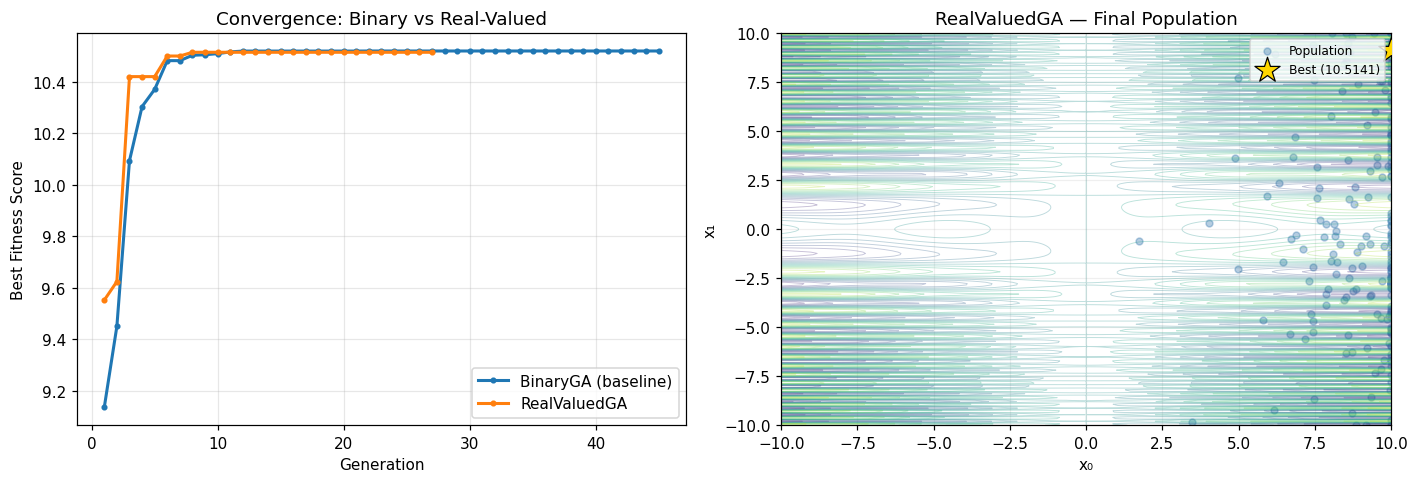

Score improvement over BinaryGA: -0.05%


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Side-by-side convergence
plot_convergence_comparison(
    binary_ga, real_ga,
    labels=['BinaryGA (baseline)', 'RealValuedGA'],
    ax=axes[0],
    title='Convergence: Binary vs Real-Valued',
)

# RealValuedGA population — smoother spread than binary
plot_population_2d(real_ga, ax=axes[1],
                   title='RealValuedGA — Final Population')
axes[1].contour(X, Y, Z, levels=18, cmap='viridis', alpha=0.3, linewidths=0.6)

plt.tight_layout()
plt.show()

improvement = (real_ga.best_score - binary_ga.best_score) / abs(binary_ga.best_score) * 100
print(f'Score improvement over BinaryGA: {improvement:+.2f}%')

---
## Step 3 — Adaptive Mutation: `AdaptiveGA`

`AdaptiveGA` extends `RealValuedGA` by **measuring population diversity** after every
generation and scaling the mutation σ accordingly:

```
diversity = mean( std(population, axis=0) )

if diversity < low_threshold:   σ ← σ × scale_up    (stagnating → explore more)
if diversity > high_threshold:  σ ← σ × scale_down  (spread out → exploit more)
```

This avoids the classic GA dilemma of choosing a mutation rate that's good for
early exploration *and* late-stage fine-tuning. The algorithm self-tunes.

In [7]:
np.random.seed(SEED)

t0 = time.time()
adaptive_ga = AdaptiveGA(
    fitness, BOUNDS,
    pop_size=200,
    n_generations=N_GENERATIONS,
    maximize=True,
    elitism=2,
    tournament_size=10,
    patience=20,
    tol=1e-5,
    scale_up=1.2,
    scale_down=0.9,
)
adaptive_solution = adaptive_ga.evolve()
adaptive_time = time.time() - t0

print(f'\nBest solution  x = {adaptive_solution[0]:.5f},  y = {adaptive_solution[1]:.5f}')
print(f'Best score     : {adaptive_ga.best_score:.6f}')
print(f'Generations    : {len(adaptive_ga.history)} / {N_GENERATIONS}')
print(f'Wall time      : {adaptive_time:.2f}s')

Generation    1 | Best score: 9.551522


  Diversity: 6.9726 | σ: 2.000000
Generation    2 | Best score: 9.623660
  Diversity: 6.9716 | σ: 2.000000
Generation    3 | Best score: 10.419548
  Diversity: 7.1105 | σ: 2.000000
Generation    4 | Best score: 10.419548
  Diversity: 7.2954 | σ: 2.000000
Generation    5 | Best score: 10.419548
  Diversity: 6.1672 | σ: 2.000000
Generation    6 | Best score: 10.499501
  Diversity: 5.9805 | σ: 2.000000
Generation    7 | Best score: 10.499501
  Diversity: 5.0244 | σ: 2.000000
Generation    8 | Best score: 10.514082
  Diversity: 3.8218 | σ: 2.000000
Generation    9 | Best score: 10.514082
  Diversity: 2.6951 | σ: 2.000000
Generation   10 | Best score: 10.514082
  Diversity: 2.8477 | σ: 2.000000
Generation   11 | Best score: 10.514082
  Diversity: 2.7990 | σ: 2.000000
Generation   12 | Best score: 10.514082
  Diversity: 2.9286 | σ: 2.000000
Generation   13 | Best score: 10.514082
  Diversity: 2.8610 | σ: 2.000000
Generation   14 | Best score: 10.514082
  Diversity: 2.8096 | σ: 2.000000
Gener

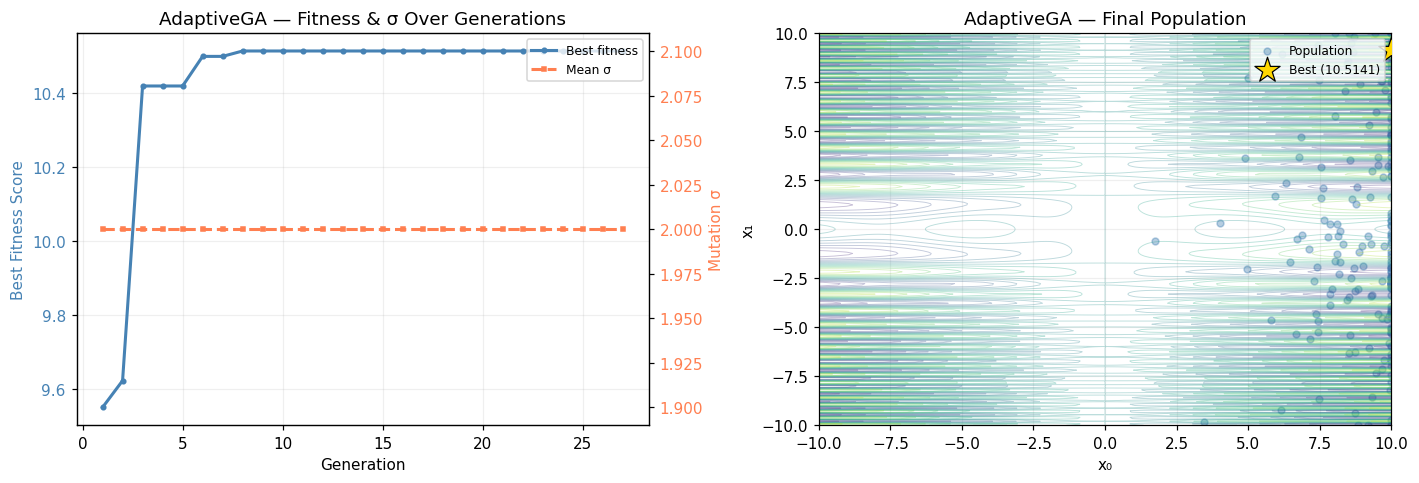

σ trajectory  : start=2.0000, min=2.0000, max=2.0000, final=2.0000
A decreasing σ means the population naturally converged; an increase mid-run means stagnation was detected and exploration was boosted.


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Dual-axis: fitness left, sigma right
plot_sigma_adaptation(
    adaptive_ga, ax=axes[0],
    title='AdaptiveGA — Fitness & σ Over Generations',
)

# Final population
plot_population_2d(adaptive_ga, ax=axes[1],
                   title='AdaptiveGA — Final Population')
axes[1].contour(X, Y, Z, levels=18, cmap='viridis', alpha=0.3, linewidths=0.6)

plt.tight_layout()
plt.show()

# Show how sigma evolved
sigmas = [s for _, s in adaptive_ga.sigma_history]
print(f'σ trajectory  : start={sigmas[0]:.4f}, min={min(sigmas):.4f}, '
      f'max={max(sigmas):.4f}, final={sigmas[-1]:.4f}')
print('A decreasing σ means the population naturally converged; '
      'an increase mid-run means stagnation was detected and exploration was boosted.')

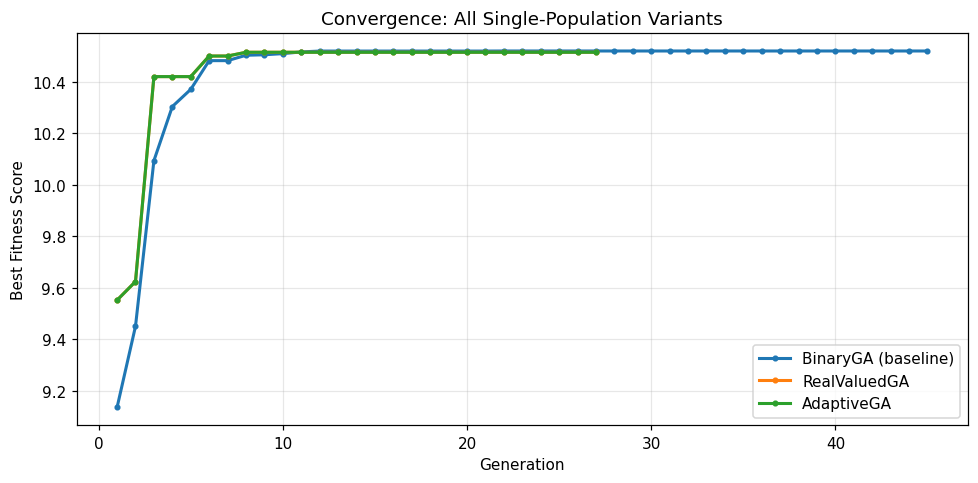

BinaryGA            score=10.51906  vs baseline: +0.00%
RealValuedGA        score=10.51408  vs baseline: -0.05%
AdaptiveGA          score=10.51408  vs baseline: -0.05%


In [9]:
# Three-way convergence comparison so far
fig, ax = plt.subplots(figsize=(9, 4.5))
plot_convergence_comparison(
    binary_ga, real_ga, adaptive_ga,
    labels=['BinaryGA (baseline)', 'RealValuedGA', 'AdaptiveGA'],
    ax=ax,
    title='Convergence: All Single-Population Variants',
)
plt.tight_layout()
plt.show()

for name, ga in [('BinaryGA', binary_ga), ('RealValuedGA', real_ga), ('AdaptiveGA', adaptive_ga)]:
    delta = (ga.best_score - binary_ga.best_score) / abs(binary_ga.best_score) * 100
    print(f'{name:<18}  score={ga.best_score:.5f}  vs baseline: {delta:+.2f}%')

---
## Step 4 — Island Model: `IslandModelGA`

Instead of one large population, the island model maintains **N independent sub-populations**
(islands). Every `migration_interval` generations, the best `n_migrants` individuals from
each island are sent to the *next* island in a ring:

```
island 0 ──► island 1 ──► island 2 ──► island 3
    ▲                                       │
    └───────────────────────────────────────┘
```

Benefits:
- Each island maintains its own **independent gene pool** → diverse search paths
- Migration **spreads good solutions** without forcing premature convergence
- Naturally **parallelisable** (each island can run on a separate core)

> Total evaluations ≈ `n_islands × pop_size_per_island × n_generations` = same order as above.

In [10]:
np.random.seed(SEED)

t0 = time.time()
island_ga = IslandModelGA(
    fitness, BOUNDS,
    n_islands=4,
    pop_size_per_island=50,   # 4 × 50 = 200 total, same as above
    n_generations=N_GENERATIONS,
    migration_interval=10,
    n_migrants=3,
    maximize=True,
    elitism=2,
)
island_solution = island_ga.evolve()
island_time = time.time() - t0

print(f'\nBest solution  x = {island_solution[0]:.5f},  y = {island_solution[1]:.5f}')
print(f'Best score     : {island_ga.best_score:.6f}')
print(f'Migration rounds : {len(island_ga.history)}')
print(f'Wall time      : {island_time:.2f}s')


=== Migration round 1/5 (gens 1–10) ===

  [Island 1]
Generation    1 | Best score: 9.223515
Generation    2 | Best score: 10.060686
Generation    3 | Best score: 10.060686
Generation    4 | Best score: 10.206821
Generation    5 | Best score: 10.529766
Generation    6 | Best score: 10.529766
Generation    7 | Best score: 10.529766
Generation    8 | Best score: 10.529766
Generation    9 | Best score: 10.529766
Generation   10 | Best score: 10.529766

  [Island 2]
Generation    1 | Best score: 9.551522
Generation    2 | Best score: 9.551522
Generation    3 | Best score: 10.355145
Generation    4 | Best score: 10.363222
Generation    5 | Best score: 10.363222
Generation    6 | Best score: 10.430515
Generation    7 | Best score: 10.476721
Generation    8 | Best score: 10.476721
Generation    9 | Best score: 10.476721
Generation   10 | Best score: 10.476721

  [Island 3]
Generation    1 | Best score: 8.593829
Generation    2 | Best score: 8.928699
Generation    3 | Best score: 9.809337
Gen

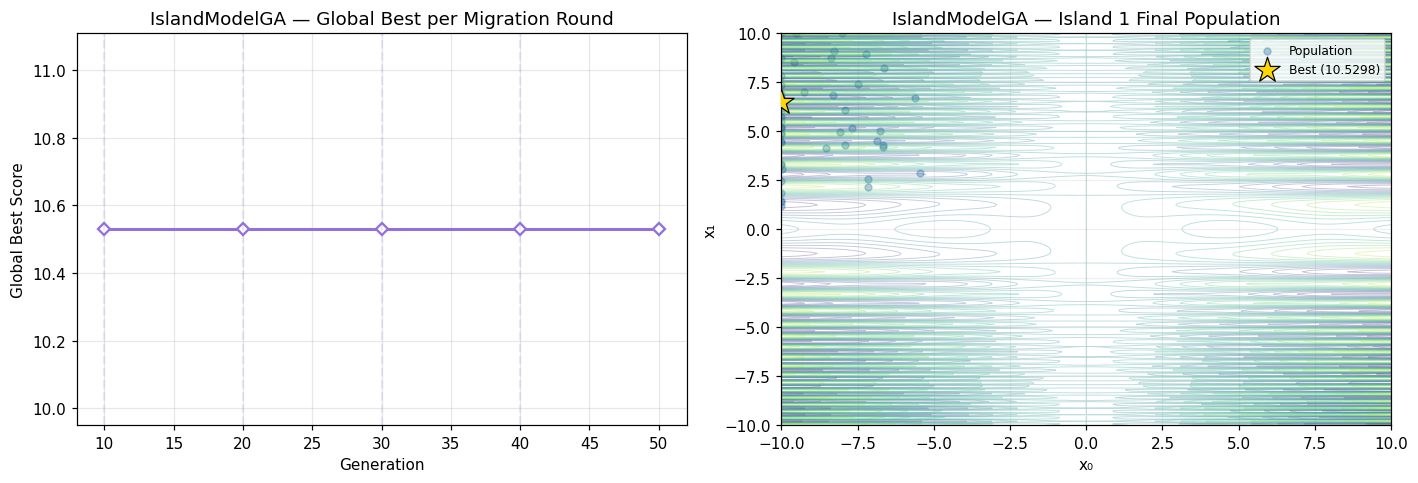

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Island model history — x-axis is generation (end of each migration round)
gens, scores = zip(*island_ga.history)
axes[0].plot(gens, scores, color='mediumpurple', linewidth=2,
             marker='D', markersize=6, markerfacecolor='white', markeredgewidth=1.5)
for g in gens[:-1]:
    axes[0].axvline(g, color='mediumpurple', alpha=0.15, linestyle='--')
axes[0].set_xlabel('Generation')
axes[0].set_ylabel('Global Best Score')
axes[0].set_title('IslandModelGA — Global Best per Migration Round')
axes[0].grid(True, alpha=0.3)

# Final population of island 0 as a representative sample
sample_island = island_ga.islands[0]
plot_population_2d(sample_island, ax=axes[1],
                   title='IslandModelGA — Island 1 Final Population')
axes[1].contour(X, Y, Z, levels=18, cmap='viridis', alpha=0.3, linewidths=0.6)

plt.tight_layout()
plt.show()

---
## Summary — Performance Across All Variants

Same fitness function, same total population budget, different strategies.

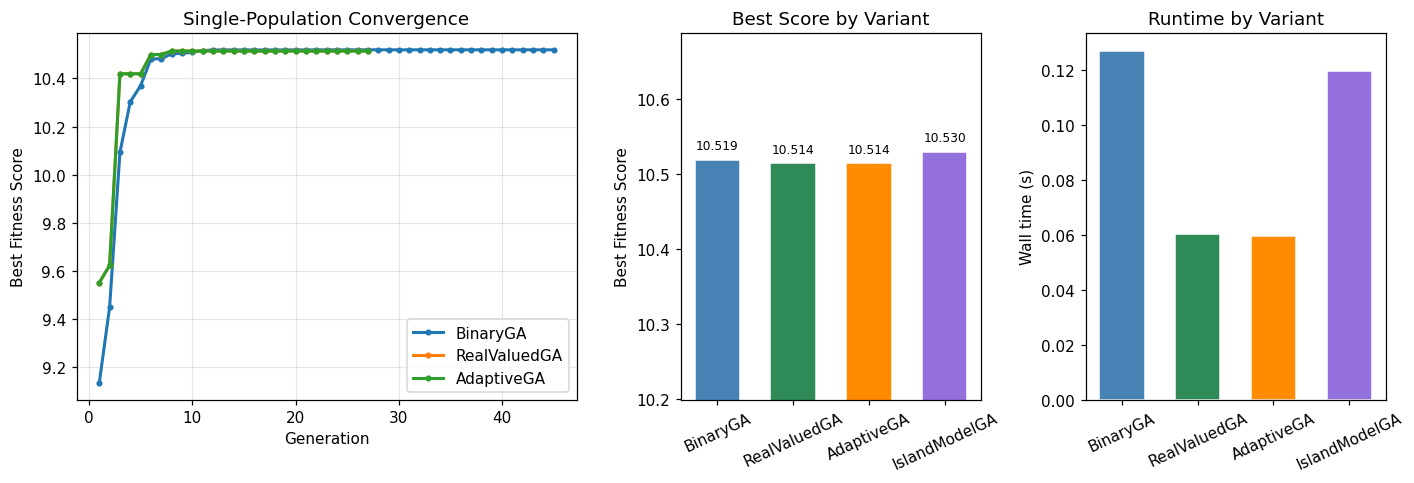

In [12]:
variants = {
    'BinaryGA':      (binary_ga,   binary_time),
    'RealValuedGA':  (real_ga,     real_time),
    'AdaptiveGA':    (adaptive_ga, adaptive_time),
    'IslandModelGA': (island_ga,   island_time),
}
colors = ['steelblue', 'seagreen', 'darkorange', 'mediumpurple']

names  = list(variants.keys())
scores = [v[0].best_score for v in variants.values()]
times  = [v[1] for v in variants.values()]
baseline = scores[0]

fig = plt.figure(figsize=(13, 4.5))
gs  = gridspec.GridSpec(1, 3, figure=fig, width_ratios=[2, 1.2, 1.2])

# --- Convergence (single-population GAs only) ---
ax0 = fig.add_subplot(gs[0])
plot_convergence_comparison(
    binary_ga, real_ga, adaptive_ga,
    labels=['BinaryGA', 'RealValuedGA', 'AdaptiveGA'],
    ax=ax0,
    title='Single-Population Convergence',
)

# --- Best score bar chart ---
ax1 = fig.add_subplot(gs[1])
bars = ax1.bar(names, scores, color=colors, width=0.6, edgecolor='white')
ax1.set_ylim(min(scores) * 0.97, max(scores) * 1.015)
ax1.set_ylabel('Best Fitness Score')
ax1.set_title('Best Score by Variant')
ax1.tick_params(axis='x', rotation=25)
for bar, score in zip(bars, scores):
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f'{score:.3f}',
        ha='center', va='bottom', fontsize=8,
    )

# --- Wall-time bar chart ---
ax2 = fig.add_subplot(gs[2])
ax2.bar(names, times, color=colors, width=0.6, edgecolor='white')
ax2.set_ylabel('Wall time (s)')
ax2.set_title('Runtime by Variant')
ax2.tick_params(axis='x', rotation=25)

plt.tight_layout()
plt.show()

In [13]:
# Print a clean summary table
header = f'{"Variant":<18} {"Best Score":>12} {"vs Baseline":>12} {"Gens Used":>10} {"Time (s)":>10}'
print(header)
print('-' * 65)
for (name, (ga, t)), col in zip(variants.items(), colors):
    score = ga.best_score
    delta = (score - baseline) / abs(baseline) * 100
    if hasattr(ga, 'history') and ga.history:
        gens_str = str(len(ga.history))
    else:
        gens_str = 'N/A'
    print(f'{name:<18} {score:>12.5f} {delta:>+11.2f}% {gens_str:>10} {t:>9.2f}s')

Variant              Best Score  vs Baseline  Gens Used   Time (s)
-----------------------------------------------------------------
BinaryGA               10.51906       +0.00%         45      0.13s
RealValuedGA           10.51408       -0.05%         27      0.06s
AdaptiveGA             10.51408       -0.05%         27      0.06s
IslandModelGA          10.52977       +0.10%          5      0.12s


---
## Key Takeaways

| What we changed | Why it helps |
|---|---|
| **Bug fixes** (mutation scope, bestChild init, parent copy) | Correctness — the original silently under-explored half the search space |
| **Elitism** | Prevents good solutions from being lost to random crossover/mutation |
| **Real-valued encoding** | Removes the encode/decode overhead; SBX produces children in physically meaningful locations |
| **Adaptive σ** | Self-tunes exploration vs exploitation — no manual σ tuning needed as the landscape changes |
| **Island model** | Diverse independent search paths prevent premature convergence; migration spreads discoveries |

### Things to try next
- Swap in a harder benchmark: **Rastrigin** `f(x) = 10n + Σ[xᵢ² − 10cos(2πxᵢ)]` has ~100 local minima in 2D
- Increase `n_jobs` in `BinaryGA` or `RealValuedGA` to see parallelised fitness evaluation speed-up
- Try `IslandModelGA(island_cls=AdaptiveGA, ...)` to get adaptive mutation *and* island diversity simultaneously
- Tune `sbx_eta` in `RealValuedGA`: lower values (η=0.5) explore widely; higher values (η=15) exploit locally